<a href="https://colab.research.google.com/github/jameshphan-png/Group-Exercise-Agentic-AI-in-Customer-Service-Sales-/blob/dev/Customer_Service_Group_Assignment_(silly_team)_(Consolidated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#THE FOLLOWING CODE IS A CHATBOT, THAT CONSOLIDATES BASED ON ALL 3 INQUIRIES TOGETHER (ORDER STATUS, REFUND POLICIES, & PRODUCT RECOMMENDATIONS)

# ============================================================
#  Acme Corp — Agentic Customer Service Chatbot
#  Uses GeminiAPI - Based on 2.5 Flash Lite
# ============================================================

**Set Up Company Details & Role Prompt**

* API Call
* Chat Conversation using LangGraph as memory > Logging conversation in a json file

Note: Keep in mind that API callings are rate-limited for Gemini, please refer to the output and keep the conversation simple, to conserve the usages against the limit.

MAIN CHAT (IF IT DOESN'T WORK DUE TO API RATE LIMIT, REFER TO THE "SANDBOX" SECTION TO TEST THE CODE USING LLMv7.IO AS A FREE API INSTEAD).


  Router Graph Structure


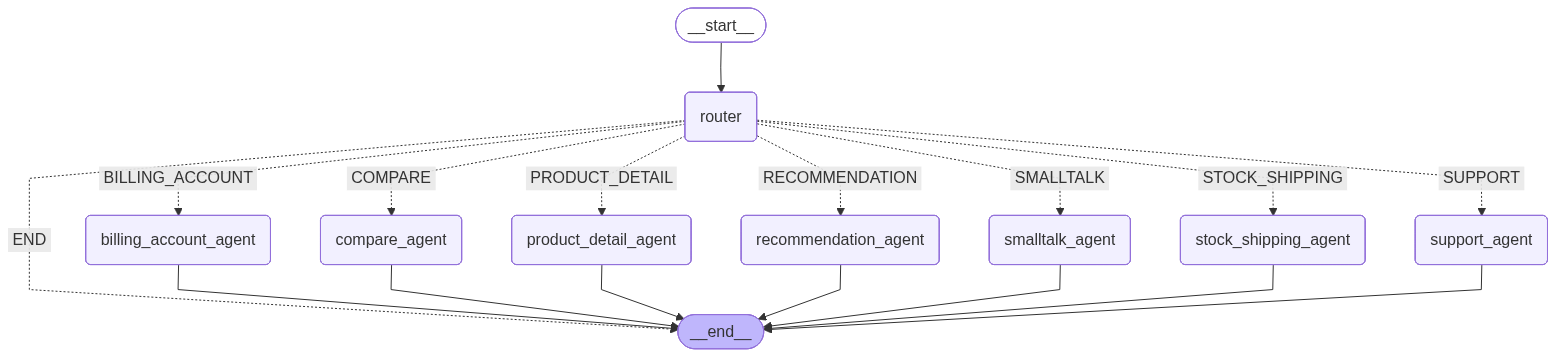

  (Graph rendered above as PNG)

  Acme Corp  -  Product Suggestions & Support
  Powered by LLM Router Agent + MemorySaver
  Monday-Friday, 9 AM - 6 PM EST
  support@acmecorp.com
  Session ID (MemorySaver thread): 20260326_004231
  Tell me what you need and I'll find the perfect laptop.
  Type 'done' at any time to end the session.
------------------------------------------------------------

  Sam: Hello there! I'm Sam, a product specialist here at Acme Corp. It's a pleasure to meet you! I'm excited to help you find the perfect premium laptop today. What are you looking for, or what brings you to us at Acme Corp?

You: Hello! I am curious to know about the policy for product refunds.

  Sam [SUPPORT]: Hi there! Thanks for reaching out to us about our refund policy. At Acme Corp, we want you to be completely happy with your purchase. We offer a 30-day hassle-free return policy, so if your new laptop isn't quite what you were expecting, you can return it within 30 days for a full refund

In [2]:
# ── Install & Imports ─────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "google-genai", "langgraph", "langchain-core", "-q"], check=True)

import os, json, re, time
from datetime import datetime
from typing import Annotated, Optional
from typing_extensions import TypedDict

from google import genai
from google.colab import userdata

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage

try:
    from IPython.display import Image, display
    IPYTHON_AVAILABLE = True
except ImportError:
    IPYTHON_AVAILABLE = False

# ── Set-up Gemini API Client ──────────────────────────────────────────────────
api_key = userdata.get('part3')
client  = genai.Client(api_key=api_key)
MODEL   = "gemini-2.5-flash-lite"

# ── Company Config ────────────────────────────────────────────────────────────
COMPANY_CONFIG = {
    "name"          : "Acme Corp",
    "industry"      : "E-Commerce",
    "support_email" : "support@acmecorp.com",
    "support_hours" : "Monday-Friday, 9 AM - 6 PM EST",
    "website"       : "https://www.acmecorp.com",
    "return_policy" : "30-day hassle-free returns",
}

# ── Product Catalogue ─────────────────────────────────────────────────────────
PRODUCTS = [
    {
        "name"       : "AlphaBook Pro",
        "price"      : 1499,
        "category"   : "Ultrabook",
        "tags"       : ["professional", "travel", "lightweight", "work", "office",
                        "portable", "business", "slim", "battery life"],
        "cpu"        : "12th Gen Intel Core i7",
        "ram"        : "16 GB DDR5",
        "storage"    : "1 TB NVMe SSD",
        "display"    : "14-inch FHD IPS, 400-nit",
        "battery"    : "Up to 12 hours",
        "weight"     : "1.3 kg",
        "shipping"   : "2-day free shipping",
        "highlights" : "Feather-light chassis built for professionals on the move. Exceptional battery life and a vibrant display.",
        "best_for"   : "Business professionals, frequent travellers, remote workers",
        "in_stock"   : True,
    },
    {
        "name"       : "GammaAir X",
        "price"      : 1399,
        "category"   : "Everyday Performance",
        "tags"       : ["student", "everyday", "value", "college", "multitasking",
                        "affordable", "thin", "light", "all-rounder"],
        "cpu"        : "AMD Ryzen 7 6800U",
        "ram"        : "32 GB DDR4",
        "storage"    : "512 GB NVMe SSD",
        "display"    : "15.6-inch FHD IPS, 300-nit",
        "battery"    : "Up to 10 hours",
        "weight"     : "1.6 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "More RAM than most laptops at this price point. Great all-rounder for students and everyday use.",
        "best_for"   : "College students, everyday users, budget-conscious buyers wanting performance",
        "in_stock"   : True,
    },
    {
        "name"       : "SpectraBook S",
        "price"      : 2499,
        "category"   : "Workstation",
        "tags"       : ["power user", "video editing", "3d rendering", "design",
                        "developer", "data science", "high performance", "workstation",
                        "music production", "engineering"],
        "cpu"        : "Intel Core i9-13900H",
        "ram"        : "64 GB DDR5",
        "storage"    : "2 TB NVMe SSD",
        "display"    : "15.6-inch 4K OLED, 600-nit",
        "battery"    : "Up to 8 hours",
        "weight"     : "2.1 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "Workstation-class power in a laptop. 4K OLED display and 64 GB RAM make it unstoppable.",
        "best_for"   : "Video editors, 3D artists, data scientists, software developers, music producers",
        "in_stock"   : True,
    },
    {
        "name"       : "OmegaPro G17",
        "price"      : 2199,
        "category"   : "Gaming",
        "tags"       : ["gaming", "gamer", "fps", "esports", "high refresh rate",
                        "streaming", "rgb", "gpu", "game", "play"],
        "cpu"        : "AMD Ryzen 9 5900HX",
        "ram"        : "32 GB DDR4",
        "storage"    : "1 TB NVMe SSD",
        "display"    : "17.3-inch FHD 165 Hz, G-Sync",
        "battery"    : "Up to 5 hours (gaming)",
        "weight"     : "2.8 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "Dominate every game with a 165 Hz G-Sync display and a powerhouse Ryzen 9 CPU + dedicated GPU.",
        "best_for"   : "Gamers, streamers, esports enthusiasts",
        "in_stock"   : True,
    },
    {
        "name"       : "NanoEdge Flex",
        "price"      : 1699,
        "category"   : "2-in-1 Convertible",
        "tags"       : ["creative", "artist", "drawing", "stylus", "touch screen",
                        "2-in-1", "convertible", "tablet", "oled", "design",
                        "flexible", "sketch", "illustration"],
        "cpu"        : "Intel Core i7-1260P",
        "ram"        : "16 GB DDR5",
        "storage"    : "512 GB NVMe SSD",
        "display"    : "13.3-inch 2K OLED Touch, 600-nit",
        "battery"    : "Up to 11 hours",
        "weight"     : "1.4 kg",
        "shipping"   : "2-day free shipping",
        "highlights" : "360-degree hinge flips between laptop and tablet mode. Stunning OLED touch display with stylus support.",
        "best_for"   : "Digital artists, illustrators, designers, note-takers, creative professionals",
        "in_stock"   : True,
    },
]

# ── Use-Case → Tag Mapping ────────────────────────────────────────────────────
USE_CASE_MAP = {
    "school"        : ["student", "everyday", "affordable", "college"],
    "college"       : ["student", "everyday", "college", "all-rounder"],
    "gaming"        : ["gaming", "gamer", "fps", "esports", "high refresh rate"],
    "work"          : ["professional", "business", "office", "work"],
    "travel"        : ["portable", "lightweight", "travel", "slim", "battery life"],
    "video editing" : ["video editing", "workstation", "power user", "high performance"],
    "design"        : ["design", "creative", "oled", "workstation"],
    "art"           : ["artist", "drawing", "stylus", "creative", "2-in-1"],
    "coding"        : ["developer", "workstation", "high performance", "data science"],
    "everyday"      : ["everyday", "all-rounder", "value", "multitasking"],
    "budget"        : ["affordable", "value", "student"],
    "creative"      : ["creative", "oled", "design", "artist", "stylus"],
    "music"         : ["music production", "workstation", "high performance"],
    "drawing"       : ["drawing", "stylus", "artist", "2-in-1", "touch screen"],
}

# ── Sam's System Prompt ───────────────────────────────────────────────────────
SYSTEM_PROMPT = f"""
You are Sam, a knowledgeable and enthusiastic product specialist for {COMPANY_CONFIG['name']},
an {COMPANY_CONFIG['industry']} company that sells premium laptops.

YOUR RESPONSIBILITIES:
1. Ask the customer smart questions to understand their needs, budget, and use case.
2. Recommend the best-matching laptop(s) from the catalogue provided to you.
3. Compare products side-by-side when the customer is deciding between options.
4. Answer detailed questions about specs, features, pricing, and shipping.
5. Handle support questions (returns, billing, account) and escalate if needed.

RECOMMENDATION APPROACH:
- Always ask about use case, budget, and any must-have features before recommending.
- Recommend 1-2 products maximum per response to avoid overwhelming the customer.
- Explain WHY a product fits their specific needs — personalise every recommendation.
- If the customer mentions a budget, never suggest products above it without flagging the price difference.
- If a product is out of stock, say so and suggest the closest alternative.

BEHAVIOUR RULES:
- Address the customer by name once you learn it.
- Keep responses conversational and helpful — not like a spec sheet.
- Never make up specs or prices — only use the product data provided to you.
- If a question requires account access or a human, say a specialist will follow up within 1 business day.
- Remember everything the customer tells you throughout this conversation.

COMPANY DETAILS:
- Support email  : {COMPANY_CONFIG['support_email']}
- Support hours  : {COMPANY_CONFIG['support_hours']}
- Return policy  : {COMPANY_CONFIG['return_policy']}
- Website        : {COMPANY_CONFIG['website']}
""".strip()

# ── Router System Prompt ──────────────────────────────────────────────────────
# Replaces the old keyword-based detect_intent() with an LLM-based router.
# The router outputs exactly one keyword; the graph's conditional edges use it
# to dispatch to the appropriate specialist agent node.
ROUTER_SYSTEM_PROMPT = """
You are a Router that reads the customer's message and outputs ONE routing keyword.

RECOMMENDATION   - Customer wants laptop suggestions or help choosing based on needs/budget.
COMPARE          - Customer wants a side-by-side comparison (words like "vs", "compare",
                   "difference", "which is better", "pros and cons").
PRODUCT_DETAIL   - Customer asks about specs, features, price, or details of a specific laptop.
STOCK_SHIPPING   - Customer asks about availability, shipping times, or delivery.
SUPPORT          - Customer has a support issue: returns, refunds, damaged/broken item, warranty.
BILLING_ACCOUNT  - Customer has a billing, payment, invoice, login, or account question.
SMALLTALK        - Greetings, goodbyes, or questions unrelated to products/orders.
END              - None of the above.

Output ONLY one keyword from the list above. No explanations, no punctuation.
""".strip()

# ── Budget Extractor ──────────────────────────────────────────────────────────
def extract_budget(message: str) -> Optional[int]:
    match = re.search(r'\$?\s*(\d{3,5})', message)
    return int(match.group(1)) if match else None

# ── Product Context Builders ──────────────────────────────────────────────────
def recommend_products(message: str, budget: Optional[int] = None) -> str:
    msg    = message.lower()
    scores = {p["name"]: 0 for p in PRODUCTS}

    for product in PRODUCTS:
        for tag in product["tags"]:
            if tag in msg:
                scores[product["name"]] += 2
        for use_case, related_tags in USE_CASE_MAP.items():
            if use_case in msg:
                for tag in related_tags:
                    if tag in product["tags"]:
                        scores[product["name"]] += 1

    eligible = [p for p in PRODUCTS if budget is None or p["price"] <= budget]
    if not eligible:
        eligible = PRODUCTS

    ranked = sorted(eligible, key=lambda p: (-scores[p["name"]], p["price"]))
    top    = ranked[:2]

    lines = ["[SYSTEM NOTE - Top product recommendation(s) based on customer needs:"]
    for i, p in enumerate(top, 1):
        stock_status = "In Stock" if p["in_stock"] else "Out of Stock"
        lines.append(
            f"\n  #{i} — {p['name']} (${p['price']}) [{stock_status}]\n"
            f"    Category  : {p['category']}\n"
            f"    CPU       : {p['cpu']}\n"
            f"    RAM       : {p['ram']}\n"
            f"    Storage   : {p['storage']}\n"
            f"    Display   : {p['display']}\n"
            f"    Battery   : {p['battery']}\n"
            f"    Weight    : {p['weight']}\n"
            f"    Shipping  : {p['shipping']}\n"
            f"    Best for  : {p['best_for']}\n"
            f"    Why it fits: {p['highlights']}"
        )
    if budget:
        lines.append(f"\n  Customer budget: ${budget}")
    lines.append(
        "\nExplain clearly WHY each product fits the customer's specific needs. "
        "Be conversational, not a spec dump. Do not reveal the scoring system.]"
    )
    return "\n".join(lines)


def build_full_catalogue() -> str:
    lines = ["[SYSTEM NOTE - Full product catalogue for comparison:"]
    for p in PRODUCTS:
        stock = "In Stock" if p["in_stock"] else "Out of Stock"
        lines.append(
            f"\n  {p['name']} — ${p['price']} [{stock}]\n"
            f"    {p['cpu']} | {p['ram']} | {p['storage']}\n"
            f"    Display: {p['display']} | Battery: {p['battery']} | Weight: {p['weight']}\n"
            f"    Best for: {p['best_for']}"
        )
    lines.append("\nCompare these honestly based on what the customer has told you they need.]")
    return "\n".join(lines)


def find_product_by_name(message: str) -> Optional[str]:
    msg = message.lower()
    for p in PRODUCTS:
        for word in p["name"].lower().split():
            if word in msg and len(word) > 3:
                stock = "In Stock" if p["in_stock"] else "Out of Stock"
                return (
                    f"[SYSTEM NOTE - Full details for {p['name']} [{stock}]:\n"
                    f"  Price    : ${p['price']}\n"
                    f"  Category : {p['category']}\n"
                    f"  CPU      : {p['cpu']}\n"
                    f"  RAM      : {p['ram']}\n"
                    f"  Storage  : {p['storage']}\n"
                    f"  Display  : {p['display']}\n"
                    f"  Battery  : {p['battery']}\n"
                    f"  Weight   : {p['weight']}\n"
                    f"  Shipping : {p['shipping']}\n"
                    f"  Best for : {p['best_for']}\n"
                    f"  Summary  : {p['highlights']}\n"
                    f"Answer the customer's specific question using these details.]"
                )
    return None

# ── Conversation Logger ───────────────────────────────────────────────────────
class ConversationLogger:
    def __init__(self, session_id: str):
        self.session_id = session_id
        self.data = {
            "session_id" : session_id,
            "started_at" : datetime.now().isoformat(),
            "company"    : COMPANY_CONFIG["name"],
            "turns"      : 0,
            "messages"   : [],
        }

    def log(self, role: str, content: str, intent: str = ""):
        entry = {"timestamp": datetime.now().isoformat(), "role": role, "content": content}
        if intent:
            entry["intent"] = intent
        self.data["messages"].append(entry)
        if role == "user":
            self.data["turns"] += 1

    def save(self):
        self.data["ended_at"] = datetime.now().isoformat()
        log_file = "support_log.json"
        try:
            existing = json.load(open(log_file)) if os.path.exists(log_file) else []
            existing.append(self.data)
            json.dump(existing, open(log_file, "w"), indent=2)
            print(f"\n  Session saved to {log_file}  (ID: {self.session_id}, turns: {self.data['turns']})")
        except Exception as e:
            print(f"\n  Could not save log: {e}")


# ════════════════════════════════════════════════════════════════════════════
# ── LangGraph: Agent State ────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════

class AgentState(TypedDict):
    """
    Shared graph state, checkpointed by MemorySaver after every node.

    messages       — full conversation history; add_messages reducer
                     *appends* new turns rather than overwriting.
    session_budget — latest budget extracted from user input; passed in
                     on every invoke so it stays current.
    route          — routing decision set by router_node, consumed by
                     the conditional edges; reset to None each invoke.
    """
    messages       : Annotated[list, add_messages]
    session_budget : Optional[int]
    route          : Optional[str]


# ════════════════════════════════════════════════════════════════════════════
# ── RouterAgent Class ─────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════

class RouterAgent:
    """
    LangGraph-based router that replaces the old keyword detect_intent().

    Graph topology:
        START
          └─► router  (LLM classifies intent into one keyword)
                ├─► recommendation_agent   → END
                ├─► compare_agent          → END
                ├─► product_detail_agent   → END
                ├─► stock_shipping_agent   → END
                ├─► support_agent          → END
                ├─► billing_account_agent  → END
                ├─► smalltalk_agent        → END
                └─► END  (direct, for unclassified inputs)

    Each specialist node:
      1. Reads the last HumanMessage from state.
      2. Augments it with the relevant product / policy context.
      3. Calls Gemini (as Sam) with the full conversation history.
      4. Returns the new AIMessage — MemorySaver checkpoints updated state.
    """

    def __init__(self):
        memory  = MemorySaver()
        builder = StateGraph(AgentState)

        # ── Register nodes ─────────────────────────────────────────────────
        builder.add_node("router",                self.router_node)
        builder.add_node("recommendation_agent",  self.recommendation_node)
        builder.add_node("compare_agent",         self.compare_node)
        builder.add_node("product_detail_agent",  self.product_detail_node)
        builder.add_node("stock_shipping_agent",  self.stock_shipping_node)
        builder.add_node("support_agent",         self.support_node)
        builder.add_node("billing_account_agent", self.billing_account_node)
        builder.add_node("smalltalk_agent",       self.smalltalk_node)

        # ── Wire edges ──────────────────────────────────────────────────────
        builder.add_edge(START, "router")

        builder.add_conditional_edges(
            "router",
            self.find_route,            # reads state["route"] set by router_node
            {
                "RECOMMENDATION"  : "recommendation_agent",
                "COMPARE"         : "compare_agent",
                "PRODUCT_DETAIL"  : "product_detail_agent",
                "STOCK_SHIPPING"  : "stock_shipping_agent",
                "SUPPORT"         : "support_agent",
                "BILLING_ACCOUNT" : "billing_account_agent",
                "SMALLTALK"       : "smalltalk_agent",
                "END"             : END,
            }
        )

        for specialist in [
            "recommendation_agent", "compare_agent", "product_detail_agent",
            "stock_shipping_agent", "support_agent", "billing_account_agent",
            "smalltalk_agent",
        ]:
            builder.add_edge(specialist, END)

        self.graph = builder.compile(checkpointer=memory)

    # ── Router Node ───────────────────────────────────────────────────────────
    def router_node(self, state: AgentState) -> dict:
        """
        LLM-based router: classifies the last user message into one keyword
        and stores it in state["route"] for the conditional edge to read.
        No messages are added to the conversation history here.
        """
        last_content = self._get_last_user_content(state)
        prompt = ROUTER_SYSTEM_PROMPT + f"\n\nCustomer: {last_content}\nRoute:"

        for attempt in range(3):
            try:
                response = client.models.generate_content(model=MODEL, contents=prompt)
                route = response.text.strip().upper()
                valid_routes = {
                    "RECOMMENDATION", "COMPARE", "PRODUCT_DETAIL", "STOCK_SHIPPING",
                    "SUPPORT", "BILLING_ACCOUNT", "SMALLTALK", "END",
                }
                if route not in valid_routes:
                    route = "SMALLTALK"   # safe fallback
                return {"route": route}
            except Exception as e:
                if "429" in str(e) and attempt < 2:
                    time.sleep(2 ** attempt)
                else:
                    raise

    def find_route(self, state: AgentState) -> str:
        """Conditional edge function — returns the route set by router_node."""
        return state.get("route") or "END"

    # ── Shared Helpers ────────────────────────────────────────────────────────
    def _get_last_user_content(self, state: AgentState) -> str:
        """Return the most recent HumanMessage content from state."""
        for msg in reversed(state["messages"]):
            if isinstance(msg, HumanMessage):
                return msg.content
        return ""

    def _call_sam(self, state: AgentState, context_note: str = "") -> dict:
        """
        Build the Gemini prompt from the full conversation history.
        The last HumanMessage is optionally augmented with a context_note
        (product data, stock info, policy text, etc.) before sending.
        Returns the new AIMessage to be appended by add_messages.
        """
        messages       = state["messages"]
        last_human_idx = max(
            (i for i, m in enumerate(messages) if isinstance(m, HumanMessage)),
            default=None,
        )

        full_prompt = SYSTEM_PROMPT + "\n\n"
        for i, msg in enumerate(messages):
            if isinstance(msg, HumanMessage):
                content = msg.content
                # Inject context into the last (current) human turn only
                if i == last_human_idx and context_note:
                    content = f"{content}\n\n{context_note}"
                full_prompt += f"Customer: {content}\n"
            elif isinstance(msg, AIMessage):
                full_prompt += f"Sam: {msg.content}\n"
        full_prompt += "Sam:"

        for attempt in range(3):
            try:
                response = client.models.generate_content(model=MODEL, contents=full_prompt)
                return {"messages": [AIMessage(content=response.text.strip())]}
            except Exception as e:
                if "429" in str(e) and attempt < 2:
                    time.sleep(2 ** attempt)
                else:
                    raise

    # ── Specialist Agent Nodes ────────────────────────────────────────────────
    def recommendation_node(self, state: AgentState) -> dict:
        """Augments with scored product recommendations filtered by budget."""
        last_content = self._get_last_user_content(state)
        budget       = state.get("session_budget")
        return self._call_sam(state, recommend_products(last_content, budget))

    def compare_node(self, state: AgentState) -> dict:
        """Augments with the full catalogue so Sam can compare side-by-side."""
        return self._call_sam(state, build_full_catalogue())

    def product_detail_node(self, state: AgentState) -> dict:
        """Augments with detailed specs for the named product (or catalogue fallback)."""
        last_content = self._get_last_user_content(state)
        note         = find_product_by_name(last_content)
        return self._call_sam(state, note if note else build_full_catalogue())

    def stock_shipping_node(self, state: AgentState) -> dict:
        """Augments with live stock + shipping info for all products."""
        lines = ["[SYSTEM NOTE - Stock and shipping info:"]
        for p in PRODUCTS:
            lines.append(
                f"  {p['name']}: {'In Stock' if p['in_stock'] else 'Out of Stock'}"
                f" | {p['shipping']}"
            )
        lines.append("]")
        return self._call_sam(state, "\n".join(lines))

    def support_node(self, state: AgentState) -> dict:
        """Augments with return policy reminder and escalation instruction."""
        context = (
            f"[SYSTEM NOTE: This is a support/warranty issue. "
            f"Remind the customer of the {COMPANY_CONFIG['return_policy']} return policy. "
            "If the issue needs account access or further investigation, escalate and mention "
            "a specialist will follow up within 1 business day.]"
        )
        return self._call_sam(state, context)

    def billing_account_node(self, state: AgentState) -> dict:
        """Augments with escalation instruction for billing/account issues."""
        context = (
            "[SYSTEM NOTE: This is a billing/account issue that requires human account access. "
            "Politely let the customer know a specialist will contact them within 1 business day.]"
        )
        return self._call_sam(state, context)

    def smalltalk_node(self, state: AgentState) -> dict:
        """Handles greetings, goodbyes, and general conversation — no augmentation."""
        return self._call_sam(state)


# ════════════════════════════════════════════════════════════════════════════
# ── Instantiate Agent + Display Router Graph ──────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════

AGENT = RouterAgent()

print("\n" + "=" * 60)
print("  Router Graph Structure")
print("=" * 60)
if IPYTHON_AVAILABLE:
    try:
        display(Image(AGENT.graph.get_graph().draw_mermaid_png()))
        print("  (Graph rendered above as PNG)")
    except Exception as e:
        print(f"  PNG render unavailable ({e}), showing Mermaid source:\n")
        print(AGENT.graph.get_graph().draw_mermaid())
else:
    print(AGENT.graph.get_graph().draw_mermaid())
print("=" * 60 + "\n")


# ── Invoke Helper ─────────────────────────────────────────────────────────────
def invoke_graph(thread_id: str, human_content: str,
                 session_budget: Optional[int]) -> str:
    """
    Send one user turn through the router graph.

    thread_id      — MemorySaver key; same ID → conversation is restored
    human_content  — raw user message (specialist nodes handle augmentation)
    session_budget — current budget tracked in Python; written into state
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = AGENT.graph.invoke(
        {
            "messages"       : [HumanMessage(content=human_content)],
            "session_budget" : session_budget,
            "route"          : None,     # router_node always overwrites this
        },
        config=config,
    )
    return result["messages"][-1].content


# ── Main Chat Session ─────────────────────────────────────────────────────────
def run_chat_session():
    thread_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    logger    = ConversationLogger(session_id=thread_id)

    session_budget: Optional[int] = None

    print("=" * 60)
    print(f"  {COMPANY_CONFIG['name']}  -  Product Suggestions & Support")
    print(f"  Powered by LLM Router Agent + MemorySaver")
    print(f"  {COMPANY_CONFIG['support_hours']}")
    print(f"  {COMPANY_CONFIG['support_email']}")
    print(f"  Session ID (MemorySaver thread): {thread_id}")
    print("=" * 60)
    print("  Tell me what you need and I'll find the perfect laptop.")
    print("  Type 'done' at any time to end the session.")
    print("-" * 60)

    # ── Greeting turn — routes to smalltalk_agent ─────────────────────────
    greeting = invoke_graph(
        thread_id,
        "Greet the customer warmly, introduce yourself as a product specialist, "
        "and ask what they are looking for today.",
        session_budget,
    )
    logger.log("assistant", greeting)
    print(f"\n  Sam: {greeting}\n")

    # ── Conversation loop ──────────────────────────────────────────────────
    while True:
        user_input = input("You: ").strip()
        if not user_input:
            continue
        if user_input.lower() in ("done", "quit", "exit", "bye", "goodbye"):
            break

        # Budget tracking stays in Python; passed to state on every invoke
        found_budget = extract_budget(user_input)
        if found_budget:
            session_budget = found_budget

        logger.log("user", user_input)
        reply = invoke_graph(thread_id, user_input, session_budget)

        # Read the route the LLM chose (for display + logging)
        snapshot = AGENT.graph.get_state({"configurable": {"thread_id": thread_id}})
        route    = snapshot.values.get("route", "unknown")

        logger.log("assistant", reply, intent=f"route:{route}")
        print(f"\n  Sam [{route}]: {reply}\n")
        print("-" * 60)

    # ── Closing turn ────────────────────────────────────────────────────────
    closing = invoke_graph(
        thread_id,
        "The customer is ending the chat. Give a friendly 1-2 sentence goodbye "
        "and mention they can email or chat again anytime.",
        session_budget,
    )
    logger.log("assistant", closing)
    print(f"\n  Sam: {closing}\n")
    print("=" * 60)

    logger.save()

    snapshot  = AGENT.graph.get_state({"configurable": {"thread_id": thread_id}})
    msg_count = len(snapshot.values["messages"])
    print(f"\n  [MemorySaver] {msg_count} messages checkpointed for thread '{thread_id}'")


# ── Entry Point ───────────────────────────────────────────────────────────────
while True:
    run_chat_session()
    again = input("\n  Start a new session? (yes / no): ").strip().lower()
    if again not in ("yes", "y"):
        print(f"\n  Thanks for shopping with {COMPANY_CONFIG['name']}. Have a great day!\n")
        break

**SANDBOX (USE THIS IF GEMINI'S API RATE LIMIT IS NOT WORKING)**

In [ ]:
# ── Install & Imports ─────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "openai", "langgraph", "langchain-core", "-q"], check=True)

import os, json, re, time
from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

import openai
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage

# ── LLM7.io Client Setup ──────────────────────────────────────────────────────
# LLM7.io is a FREE OpenAI-compatible gateway — no API key required.
# For higher rate limits, get a free token at https://token.llm7.io
# and replace "unused" below with your token, or store it in Colab secrets.

try:
    from google.colab import userdata
    LLM7_TOKEN = userdata.get("llm7_token") or "unused"
except Exception:
    LLM7_TOKEN = os.environ.get("LLM7_TOKEN", "unused")

LLM7_CLIENT = openai.OpenAI(
    base_url="https://api.llm7.io/v1",
    api_key=LLM7_TOKEN,        # "unused" works for basic / no-token access
)

# Available free models on LLM7.io (swap MODEL to any you prefer):
#   "gpt-4"               — GPT-4 class
#   "gpt-4o"              — GPT-4o class
#   "deepseek-chat"       — DeepSeek V3
#   "mistral-large-latest"— Mistral Large
MODEL = "gpt-4o"

# ── Company Config ────────────────────────────────────────────────────────────
COMPANY_CONFIG = {
    "name"          : "Acme Corp",
    "industry"      : "E-Commerce",
    "support_email" : "support@acmecorp.com",
    "support_hours" : "Monday-Friday, 9 AM - 6 PM EST",
    "website"       : "https://www.acmecorp.com",
    "return_policy" : "30-day hassle-free returns",
}

# ── Product Catalogue ─────────────────────────────────────────────────────────
PRODUCTS = [
    {
        "name"       : "AlphaBook Pro",
        "price"      : 1499,
        "category"   : "Ultrabook",
        "tags"       : ["professional", "travel", "lightweight", "work", "office",
                        "portable", "business", "slim", "battery life"],
        "cpu"        : "12th Gen Intel Core i7",
        "ram"        : "16 GB DDR5",
        "storage"    : "1 TB NVMe SSD",
        "display"    : "14-inch FHD IPS, 400-nit",
        "battery"    : "Up to 12 hours",
        "weight"     : "1.3 kg",
        "shipping"   : "2-day free shipping",
        "highlights" : "Feather-light chassis built for professionals on the move. Exceptional battery life and a vibrant display.",
        "best_for"   : "Business professionals, frequent travellers, remote workers",
        "in_stock"   : True,
    },
    {
        "name"       : "GammaAir X",
        "price"      : 1399,
        "category"   : "Everyday Performance",
        "tags"       : ["student", "everyday", "value", "college", "multitasking",
                        "affordable", "thin", "light", "all-rounder"],
        "cpu"        : "AMD Ryzen 7 6800U",
        "ram"        : "32 GB DDR4",
        "storage"    : "512 GB NVMe SSD",
        "display"    : "15.6-inch FHD IPS, 300-nit",
        "battery"    : "Up to 10 hours",
        "weight"     : "1.6 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "More RAM than most laptops at this price point. Great all-rounder for students and everyday use.",
        "best_for"   : "College students, everyday users, budget-conscious buyers wanting performance",
        "in_stock"   : True,
    },
    {
        "name"       : "SpectraBook S",
        "price"      : 2499,
        "category"   : "Workstation",
        "tags"       : ["power user", "video editing", "3d rendering", "design",
                        "developer", "data science", "high performance", "workstation",
                        "music production", "engineering"],
        "cpu"        : "Intel Core i9-13900H",
        "ram"        : "64 GB DDR5",
        "storage"    : "2 TB NVMe SSD",
        "display"    : "15.6-inch 4K OLED, 600-nit",
        "battery"    : "Up to 8 hours",
        "weight"     : "2.1 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "Workstation-class power in a laptop. 4K OLED display and 64 GB RAM make it unstoppable.",
        "best_for"   : "Video editors, 3D artists, data scientists, software developers, music producers",
        "in_stock"   : True,
    },
    {
        "name"       : "OmegaPro G17",
        "price"      : 2199,
        "category"   : "Gaming",
        "tags"       : ["gaming", "gamer", "fps", "esports", "high refresh rate",
                        "streaming", "rgb", "gpu", "game", "play"],
        "cpu"        : "AMD Ryzen 9 5900HX",
        "ram"        : "32 GB DDR4",
        "storage"    : "1 TB NVMe SSD",
        "display"    : "17.3-inch FHD 165 Hz, G-Sync",
        "battery"    : "Up to 5 hours (gaming)",
        "weight"     : "2.8 kg",
        "shipping"   : "5-7 day standard shipping",
        "highlights" : "Dominate every game with a 165 Hz G-Sync display and a powerhouse Ryzen 9 CPU + dedicated GPU.",
        "best_for"   : "Gamers, streamers, esports enthusiasts",
        "in_stock"   : True,
    },
    {
        "name"       : "NanoEdge Flex",
        "price"      : 1699,
        "category"   : "2-in-1 Convertible",
        "tags"       : ["creative", "artist", "drawing", "stylus", "touch screen",
                        "2-in-1", "convertible", "tablet", "oled", "design",
                        "flexible", "sketch", "illustration"],
        "cpu"        : "Intel Core i7-1260P",
        "ram"        : "16 GB DDR5",
        "storage"    : "512 GB NVMe SSD",
        "display"    : "13.3-inch 2K OLED Touch, 600-nit",
        "battery"    : "Up to 11 hours",
        "weight"     : "1.4 kg",
        "shipping"   : "2-day free shipping",
        "highlights" : "360-degree hinge flips between laptop and tablet mode. Stunning OLED touch display with stylus support.",
        "best_for"   : "Digital artists, illustrators, designers, note-takers, creative professionals",
        "in_stock"   : True,
    },
]

# ── Use-Case → Tag Mapping ────────────────────────────────────────────────────
USE_CASE_MAP = {
    "school"        : ["student", "everyday", "affordable", "college"],
    "college"       : ["student", "everyday", "college", "all-rounder"],
    "gaming"        : ["gaming", "gamer", "fps", "esports", "high refresh rate"],
    "work"          : ["professional", "business", "office", "work"],
    "travel"        : ["portable", "lightweight", "travel", "slim", "battery life"],
    "video editing" : ["video editing", "workstation", "power user", "high performance"],
    "design"        : ["design", "creative", "oled", "workstation"],
    "art"           : ["artist", "drawing", "stylus", "creative", "2-in-1"],
    "coding"        : ["developer", "workstation", "high performance", "data science"],
    "everyday"      : ["everyday", "all-rounder", "value", "multitasking"],
    "budget"        : ["affordable", "value", "student"],
    "creative"      : ["creative", "oled", "design", "artist", "stylus"],
    "music"         : ["music production", "workstation", "high performance"],
    "drawing"       : ["drawing", "stylus", "artist", "2-in-1", "touch screen"],
}

# ── System Prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = f"""
You are Sam, a knowledgeable and enthusiastic product specialist for {COMPANY_CONFIG['name']},
an {COMPANY_CONFIG['industry']} company that sells premium laptops.

YOUR RESPONSIBILITIES:
1. Ask the customer smart questions to understand their needs, budget, and use case.
2. Recommend the best-matching laptop(s) from the catalogue provided to you.
3. Compare products side-by-side when the customer is deciding between options.
4. Answer detailed questions about specs, features, pricing, and shipping.
5. Handle support questions (returns, billing, account) and escalate if needed.

RECOMMENDATION APPROACH:
- Always ask about use case, budget, and any must-have features before recommending.
- Recommend 1-2 products maximum per response to avoid overwhelming the customer.
- Explain WHY a product fits their specific needs — personalise every recommendation.
- If the customer mentions a budget, never suggest products above it without flagging the price difference.
- If a product is out of stock, say so and suggest the closest alternative.

BEHAVIOUR RULES:
- Address the customer by name once you learn it.
- Keep responses conversational and helpful — not like a spec sheet.
- Never make up specs or prices — only use the product data provided to you.
- If a question requires account access or a human, say a specialist will follow up within 1 business day.
- Remember everything the customer tells you throughout this conversation.

COMPANY DETAILS:
- Support email  : {COMPANY_CONFIG['support_email']}
- Support hours  : {COMPANY_CONFIG['support_hours']}
- Return policy  : {COMPANY_CONFIG['return_policy']}
- Website        : {COMPANY_CONFIG['website']}
""".strip()

# ── Intent Detection ──────────────────────────────────────────────────────────
INTENT_KEYWORDS = {
    "get_recommendation" : ["recommend", "suggest", "which laptop", "what laptop",
                            "best for", "help me choose", "looking for", "need a laptop",
                            "want to buy", "which one", "what should i get"],
    "compare"            : ["compare", "difference between", "vs", "versus",
                            "better", "which is better", "pros and cons"],
    "product_detail"     : ["tell me about", "more about", "specs", "specifications",
                            "features", "details", "how much", "price", "weight",
                            "battery", "display", "ram", "storage", "cpu", "processor",
                            "alphabook", "gammaair", "spectrabook", "omegapro", "nanoedge"],
    "stock_shipping"     : ["in stock", "available", "shipping", "how long", "delivery",
                            "when will", "2-day", "ship"],
    "budget"             : ["budget", "cheap", "affordable", "under", "less than",
                            "price range", "how much can", "spend"],
    "use_case"           : ["school", "college", "gaming", "work", "travel", "video editing",
                            "design", "art", "coding", "music", "drawing", "creative",
                            "everyday", "professional", "student"],
    "support"            : ["return", "refund", "broken", "not working", "warranty",
                            "repair", "defective", "damaged", "exchange"],
    "billing"            : ["charge", "bill", "payment", "invoice", "receipt", "paid"],
    "account"            : ["login", "password", "account", "sign in", "verification"],
}

def detect_intent(message: str) -> str:
    msg = message.lower()
    for intent, keywords in INTENT_KEYWORDS.items():
        if any(kw in msg for kw in keywords):
            return intent
    return "general"

# ── Budget Extractor ──────────────────────────────────────────────────────────
def extract_budget(message: str):
    match = re.search(r'\$?\s*(\d{3,5})', message)
    return int(match.group(1)) if match else None

# ── Product Recommendation Engine ────────────────────────────────────────────
def recommend_products(message: str, budget: int = None) -> str:
    msg    = message.lower()
    scores = {p["name"]: 0 for p in PRODUCTS}

    for product in PRODUCTS:
        for tag in product["tags"]:
            if tag in msg:
                scores[product["name"]] += 2
        for use_case, related_tags in USE_CASE_MAP.items():
            if use_case in msg:
                for tag in related_tags:
                    if tag in product["tags"]:
                        scores[product["name"]] += 1

    eligible = [p for p in PRODUCTS if budget is None or p["price"] <= budget]
    if not eligible:
        eligible = PRODUCTS

    ranked = sorted(eligible, key=lambda p: (-scores[p["name"]], p["price"]))
    top    = ranked[:2]

    lines = ["[SYSTEM NOTE - Top product recommendation(s) based on customer needs:"]
    for i, p in enumerate(top, 1):
        stock_status = "In Stock" if p["in_stock"] else "Out of Stock"
        lines.append(
            f"\n  #{i} — {p['name']} (${p['price']}) [{stock_status}]\n"
            f"    Category  : {p['category']}\n"
            f"    CPU       : {p['cpu']}\n"
            f"    RAM       : {p['ram']}\n"
            f"    Storage   : {p['storage']}\n"
            f"    Display   : {p['display']}\n"
            f"    Battery   : {p['battery']}\n"
            f"    Weight    : {p['weight']}\n"
            f"    Shipping  : {p['shipping']}\n"
            f"    Best for  : {p['best_for']}\n"
            f"    Why it fits: {p['highlights']}"
        )
    if budget:
        lines.append(f"\n  Customer budget: ${budget}")
    lines.append(
        "\nExplain clearly WHY each product fits the customer's specific needs. "
        "Be conversational, not a spec dump. Do not reveal the scoring system.]"
    )
    return "\n".join(lines)

def build_full_catalogue() -> str:
    lines = ["[SYSTEM NOTE - Full product catalogue for comparison:"]
    for p in PRODUCTS:
        stock = "In Stock" if p["in_stock"] else "Out of Stock"
        lines.append(
            f"\n  {p['name']} — ${p['price']} [{stock}]\n"
            f"    {p['cpu']} | {p['ram']} | {p['storage']}\n"
            f"    Display: {p['display']} | Battery: {p['battery']} | Weight: {p['weight']}\n"
            f"    Best for: {p['best_for']}"
        )
    lines.append("\nCompare these honestly based on what the customer has told you they need.]")
    return "\n".join(lines)

def find_product_by_name(message: str) -> str | None:
    msg = message.lower()
    for p in PRODUCTS:
        for word in p["name"].lower().split():
            if word in msg and len(word) > 3:
                stock = "In Stock" if p["in_stock"] else "Out of Stock"
                return (
                    f"[SYSTEM NOTE - Full details for {p['name']} [{stock}]:\n"
                    f"  Price    : ${p['price']}\n"
                    f"  Category : {p['category']}\n"
                    f"  CPU      : {p['cpu']}\n"
                    f"  RAM      : {p['ram']}\n"
                    f"  Storage  : {p['storage']}\n"
                    f"  Display  : {p['display']}\n"
                    f"  Battery  : {p['battery']}\n"
                    f"  Weight   : {p['weight']}\n"
                    f"  Shipping : {p['shipping']}\n"
                    f"  Best for : {p['best_for']}\n"
                    f"  Summary  : {p['highlights']}\n"
                    f"Answer the customer's specific question using these details.]"
                )
    return None

# ── Conversation Logger ───────────────────────────────────────────────────────
class ConversationLogger:
    def __init__(self, session_id: str):
        self.session_id = session_id
        self.data = {
            "session_id" : session_id,
            "started_at" : datetime.now().isoformat(),
            "company"    : COMPANY_CONFIG["name"],
            "model"      : MODEL,
            "provider"   : "LLM7.io",
            "turns"      : 0,
            "messages"   : [],
        }

    def log(self, role: str, content: str, intent: str = ""):
        entry = {"timestamp": datetime.now().isoformat(), "role": role, "content": content}
        if intent:
            entry["intent"] = intent
        self.data["messages"].append(entry)
        if role == "user":
            self.data["turns"] += 1

    def save(self):
        self.data["ended_at"] = datetime.now().isoformat()
        log_file = "support_log.json"
        try:
            existing = json.load(open(log_file)) if os.path.exists(log_file) else []
            existing.append(self.data)
            json.dump(existing, open(log_file, "w"), indent=2)
            print(f"\n  Session saved → {log_file}  (ID: {self.session_id}, turns: {self.data['turns']})")
        except Exception as e:
            print(f"\n  Could not save log: {e}")

# ── LangGraph Setup ──────────────────────────────────────────────────────────

class AgentState(TypedDict):
    messages       : Annotated[list, add_messages]  # add_messages reducer appends new turns
    session_budget : int | None                     # persisted by MemorySaver across turns


def llm7_node(state: AgentState) -> dict:
    """
    Graph node: converts LangGraph message objects into OpenAI-format dicts,
    calls LLM7.io (OpenAI-compatible endpoint), returns the new AIMessage.

    Because LLM7.io follows the OpenAI chat-completions spec we pass a proper
    system message + conversation history — no flat-string prompt needed.
    MemorySaver stores the full AgentState after every .invoke() call.
    """
    # Build the OpenAI-style messages list: system prompt first, then history
    api_messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            api_messages.append({"role": "user",      "content": msg.content})
        elif isinstance(msg, AIMessage):
            api_messages.append({"role": "assistant", "content": msg.content})

    for attempt in range(3):
        try:
            response = LLM7_CLIENT.chat.completions.create(
                model    = MODEL,
                messages = api_messages,
            )
            reply = response.choices[0].message.content.strip()
            # Return only the *new* AIMessage — add_messages reducer merges it
            return {"messages": [AIMessage(content=reply)]}

        except openai.RateLimitError:
            if attempt < 2:
                wait = 2 ** attempt
                print(f"  Rate limited by LLM7.io, retrying in {wait}s... "
                      f"(tip: get a free token at https://token.llm7.io)")
                time.sleep(wait)
            else:
                raise

        except openai.APIConnectionError as e:
            raise RuntimeError(
                "Could not reach LLM7.io. Check your internet connection."
            ) from e


def build_graph() -> StateGraph:
    """
    Single-node StateGraph with MemorySaver as the checkpointer.

    MemorySaver snapshots AgentState (messages + budget) after every
    .invoke() call, keyed by thread_id. Passing the same thread_id
    on the next turn automatically restores the full conversation —
    no manual history management needed.

    Swapping MemorySaver → SqliteSaver / PostgresSaver later would
    make history persist across process restarts with zero other changes.
    """
    memory  = MemorySaver()
    builder = StateGraph(AgentState)
    builder.add_node("sam", llm7_node)
    builder.add_edge(START, "sam")
    builder.add_edge("sam", END)
    return builder.compile(checkpointer=memory)


GRAPH = build_graph()          # One shared graph; MemorySaver lives inside it


def invoke_graph(thread_id: str, human_content: str,
                 session_budget: int | None) -> str:
    """
    Send one user turn to the graph and return Sam's reply.

    thread_id      — MemorySaver key; same value = restored conversation
    human_content  — the (possibly context-augmented) user message
    session_budget — latest extracted budget, stored in state for persistence
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = GRAPH.invoke(
        {
            "messages"       : [HumanMessage(content=human_content)],
            "session_budget" : session_budget,
        },
        config=config,
    )
    return result["messages"][-1].content


# ── Main Chat Session ─────────────────────────────────────────────────────────
def run_chat_session():
    thread_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    logger    = ConversationLogger(session_id=thread_id)

    session_budget: int | None = None

    print("=" * 60)
    print(f"  {COMPANY_CONFIG['name']}  -  Product Suggestions & Support")
    print(f"  Powered by LLM7.io (free)  |  Model: {MODEL}")
    print(f"  {COMPANY_CONFIG['support_hours']}")
    print(f"  {COMPANY_CONFIG['support_email']}")
    print(f"  Session ID (MemorySaver thread): {thread_id}")
    print("=" * 60)
    print("  Tell me what you need and I'll find the perfect laptop.")
    print("  Type 'done' at any time to end the session.")
    print("-" * 60)

    # ── Greeting turn ─────────────────────────────────────────────────────────
    greeting = invoke_graph(
        thread_id,
        "Greet the customer warmly, introduce yourself as a product specialist, "
        "and ask what they are looking for today.",
        session_budget,
    )
    logger.log("assistant", greeting)
    print(f"\n  Sam: {greeting}\n")

    # ── Conversation loop ──────────────────────────────────────────────────────
    while True:
        user_input = input("You: ").strip()
        if not user_input:
            continue
        if user_input.lower() in ("done", "quit", "exit", "bye", "goodbye"):
            break

        intent = detect_intent(user_input)
        logger.log("user", user_input, intent=intent)

        found_budget = extract_budget(user_input)
        if found_budget:
            session_budget = found_budget

        # ── Augment user message with product / support context ────────────
        if intent in ("get_recommendation", "use_case", "budget"):
            augmented = f"{user_input}\n\n{recommend_products(user_input, session_budget)}"

        elif intent == "compare":
            augmented = f"{user_input}\n\n{build_full_catalogue()}"

        elif intent == "product_detail":
            product_note = find_product_by_name(user_input)
            augmented    = (f"{user_input}\n\n{product_note}"
                            if product_note
                            else f"{user_input}\n\n{build_full_catalogue()}")

        elif intent == "stock_shipping":
            lines = ["[SYSTEM NOTE - Stock and shipping info:"]
            for p in PRODUCTS:
                lines.append(
                    f"  {p['name']}: {'In Stock' if p['in_stock'] else 'Out of Stock'}"
                    f" | {p['shipping']}"
                )
            lines.append("]")
            augmented = f"{user_input}\n\n" + "\n".join(lines)

        elif intent == "support":
            augmented = (
                f"{user_input}\n\n[SYSTEM NOTE: This is a support/warranty issue. "
                f"Remind the customer of the {COMPANY_CONFIG['return_policy']} return policy. "
                "If the issue needs account access or further investigation, escalate and mention "
                "a specialist will follow up within 1 business day.]"
            )

        elif intent in ("billing", "account"):
            augmented = (
                f"{user_input}\n\n[SYSTEM NOTE: Intent = {intent}. "
                "This requires human account access. Politely let the customer know "
                "a specialist will contact them within 1 business day at their email.]"
            )

        else:
            augmented = user_input

        # ── Invoke graph — MemorySaver restores full history via thread_id ──
        reply = invoke_graph(thread_id, augmented, session_budget)
        logger.log("assistant", reply)

        print(f"\n  Sam: {reply}\n")
        print("-" * 60)

    # ── Closing turn ──────────────────────────────────────────────────────────
    closing = invoke_graph(
        thread_id,
        "The customer is ending the chat. Give a friendly 1-2 sentence goodbye "
        "and mention they can email or chat again anytime.",
        session_budget,
    )
    logger.log("assistant", closing)
    print(f"\n  Sam: {closing}\n")
    print("=" * 60)

    logger.save()

    # ── Show MemorySaver checkpoint summary ───────────────────────────────────
    snapshot = GRAPH.get_state({"configurable": {"thread_id": thread_id}})
    msg_count = len(snapshot.values["messages"])
    print(f"\n  [MemorySaver] {msg_count} messages checkpointed for thread '{thread_id}'")


# ── Entry Point ───────────────────────────────────────────────────────────────
while True:
    run_chat_session()
    again = input("\n  Start a new session? (yes / no): ").strip().lower()
    if again not in ("yes", "y"):
        print(f"\n  Thanks for shopping with {COMPANY_CONFIG['name']}. Have a great day!\n")
        break

  Acme Corp  -  Product Suggestions & Support
  Powered by LLM7.io (free)  |  Model: gpt-4o
  Monday-Friday, 9 AM - 6 PM EST
  support@acmecorp.com
  Session ID (MemorySaver thread): 20260322_021430
  Tell me what you need and I'll find the perfect laptop.
  Type 'done' at any time to end the session.
------------------------------------------------------------

  Sam: Hello! Welcome to Acme Corp. I'm Sam, your dedicated product specialist. I'm here to help you find the perfect premium laptop to meet your needs. What are you looking for today? Are you in the market for a new laptop, or do you have any specific questions about our current offerings?

You: I am looking for an order refund. What are the policies?

  Sam: I'm sorry to hear you're having trouble with your order. Our return policy allows for a full refund within 30 days of purchase, provided the item is returned in its original condition. To initiate a return, please visit our website and navigate to the "Returns" section un